# Computer Exercise 1.1 — Problem 8

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 1.1 Introduction (continued)
> **풀이 일자**: Day 03
> **언어**: Python 3 (NumPy / Pandas / Matplotlib)


## 1. 문제 (원문)

> **8.** Compute the variance of $n$ sample values $x_1, \ldots, x_n$ in two ways:
> (a) the *two-pass* (textbook) formula $\sigma^2 = \tfrac{1}{n}\sum (x_i - \bar x)^2$, and
> (b) the algebraically equivalent *one-pass* formula $\sigma^2 = \tfrac{1}{n}\sum x_i^2 - \bar x^2$.
> Test both on data with mean $\mu$ much larger than the standard deviation $s$ and explain why the two formulas can disagree by many orders of magnitude.

### 한국어 풀이용 정리
표본 $x_1, \ldots, x_n$ 의 분산을 두 가지 *대수적으로 동치인* 식으로 계산한다.

* **two-pass (textbook)**: 평균을 먼저 구해 두 번 훑는 안정적인 방법
* **one-pass (computational)**: 한 번 훑으면서 $\sum x_i$ 와 $\sum x_i^2$ 를 동시에 누적하는 방법

데이터 평균 $\mu$ 가 표준편차 $s$ 에 비해 압도적으로 클 때, one-pass 공식은 **catastrophic cancellation** 으로 인해 크게 빗나간다.


## 2. 수학적 배경

### 2.1 두 공식의 동치성
표본평균을 $\bar x = \tfrac{1}{n}\sum x_i$ 라 하면

$$
\sum_{i=1}^{n} (x_i - \bar x)^2 \;=\; \sum_{i=1}^{n} x_i^2 \;-\; n\,\bar x^2 .
$$

좌변(2-pass)과 우변(1-pass)은 **대수적으로 같다**.

### 2.2 부동소수점에서 깨지는 이유
$\mu \gg s$ 인 경우 $x_i \approx \mu + \mathcal{O}(s)$ 이므로

$$
\sum x_i^2 \;\approx\; n\mu^2 + 2\mu \sum (x_i - \mu) + \sum (x_i - \mu)^2,
$$

$$
n\bar x^2 \;\approx\; n\mu^2 + 2\mu \sum (x_i - \mu) + \mathcal{O}(s^2/n).
$$

두 항 모두 $\sim n\mu^2$ 만큼 크고, 그 차에 우리가 원하는 작은 양 $\mathcal{O}(s^2)$ 가 숨어 있다. 따라서 **상대오차가 크기 비율 $\mu^2/s^2$ 만큼 증폭**된다 — 전형적인 catastrophic cancellation.

### 2.3 안정성 추정
1-pass 결과의 상대오차는 대략

$$
\frac{|\widehat{\sigma^2} - \sigma^2|}{\sigma^2} \;\lesssim\; \varepsilon_{\text{mach}} \cdot \frac{\mu^2}{s^2} .
$$

따라서 $\mu/s$ 가 $10^4$ 만 되어도 double precision (~$10^{-16}$) 의 정확도가 $10^{-8}$ 수준으로 떨어지고, $10^8$ 이면 *부호조차* 음수로 나오기도 한다. 분산은 $\ge 0$ 이어야 하므로 음수는 곧 **수치적 파산**의 신호이다.

\boxed{\;\widehat{\sigma^2}_{\text{1-pass}} \text{ may even become negative when } \mu \gg s\;}


## 3. 풀이 흐름

1. 임의의 표준편차 $s$ 와 다양한 평균 시프트 $\mu \in \{0, 1, 10^2, 10^4, 10^6, 10^8\}$ 으로 데이터를 만든다.
   - 기준 분포: $\mathcal{N}(0, s^2)$ 표본을 $\mu$ 만큼 평행이동.
2. 동일 데이터에 대해
   - `var_two_pass(x)` (안정)
   - `var_one_pass(x)` (불안정)
   - 그리고 *기준값*으로 `np.float128` 또는 분산의 정의 $\frac{1}{n}\sum (x_i - \bar x)^2$ 를 매우 큰 정밀도로 계산한 결과
3. 표로 비교 → 1-pass가 어떤 $\mu$ 부터 망가지는지 확인.
4. log-log 그래프: $\mu/s$ 대비 상대오차.
5. 결과 해석.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(20260506)

def var_two_pass(x):
    x = np.asarray(x, dtype=np.float64)
    m = x.mean()
    return np.mean((x - m) ** 2)

def var_one_pass(x):
    x = np.asarray(x, dtype=np.float64)
    n = x.size
    s1 = x.sum()
    s2 = (x * x).sum()
    return s2 / n - (s1 / n) ** 2

def var_reference(x):
    # Welford 알고리즘 (1-pass이지만 수치적으로 안정) 으로 기준값 산정
    n = 0
    mean = 0.0
    M2 = 0.0
    for v in x:
        n += 1
        delta = v - mean
        mean += delta / n
        delta2 = v - mean
        M2 += delta * delta2
    return M2 / n


In [2]:
# 데이터: 평균 mu, 표준편차 s = 1, n = 10^5
n_samples = 100_000
s_true    = 1.0
base      = rng.normal(loc=0.0, scale=s_true, size=n_samples)

mus = [0.0, 1.0, 1e2, 1e4, 1e6, 1e8]
rows = []
for mu in mus:
    x = base + mu
    v_two   = var_two_pass(x)
    v_one   = var_one_pass(x)
    v_ref   = var_reference(x)
    rows.append({
        "mu":          mu,
        "mu/s":        mu / s_true,
        "two-pass":    v_two,
        "one-pass":    v_one,
        "reference":   v_ref,
        "|rel err| 2p": abs(v_two - v_ref) / abs(v_ref),
        "|rel err| 1p": abs(v_one - v_ref) / abs(v_ref),
    })

df = pd.DataFrame(rows)
pd.set_option("display.float_format", lambda v: f"{v:.4e}")
df


,mu,mu/s,two-pass,one-pass,reference,|rel err| 2p,|rel err| 1p
0,0.0000e+00,0.0000e+00,9.9947e-01,9.9947e-01,9.9947e-01,9.8863e-15,9.8863e-15
1,1.0000e+00,1.0000e+00,9.9947e-01,9.9947e-01,9.9947e-01,1.0331e-14,1.0220e-14
2,1.0000e+02,1.0000e+02,9.9947e-01,9.9947e-01,9.9947e-01,4.9987e-15,2.1530e-12
3,1.0000e+04,1.0000e+04,9.9947e-01,9.9947e-01,9.9947e-01,4.9043e-13,3.0289e-08
4,1.0000e+06,1.0000e+06,9.9947e-01,1.0000e+00,9.9947e-01,1.3677e-11,5.3482e-04
5,1.0000e+08,1.0000e+08,9.9947e-01,6.0000e+00,9.9947e-01,3.0074e-10,5.0032e+00


In [3]:
# 1-pass가 음수로 떨어지는 영역 명시
import numpy as _np

def sign_label(v):
    if v < 0:    return "NEGATIVE (!)"
    if v == 0:   return "zero"
    return "positive"

df["one-pass sign"] = df["one-pass"].apply(sign_label)
df[["mu", "mu/s", "two-pass", "one-pass", "one-pass sign",
    "|rel err| 2p", "|rel err| 1p"]]


,mu,mu/s,two-pass,one-pass,one-pass sign,|rel err| 2p,|rel err| 1p
0,0.0000e+00,0.0000e+00,9.9947e-01,9.9947e-01,positive,9.8863e-15,9.8863e-15
1,1.0000e+00,1.0000e+00,9.9947e-01,9.9947e-01,positive,1.0331e-14,1.0220e-14
2,1.0000e+02,1.0000e+02,9.9947e-01,9.9947e-01,positive,4.9987e-15,2.1530e-12
3,1.0000e+04,1.0000e+04,9.9947e-01,9.9947e-01,positive,4.9043e-13,3.0289e-08
4,1.0000e+06,1.0000e+06,9.9947e-01,1.0000e+00,positive,1.3677e-11,5.3482e-04
5,1.0000e+08,1.0000e+08,9.9947e-01,6.0000e+00,positive,3.0074e-10,5.0032e+00


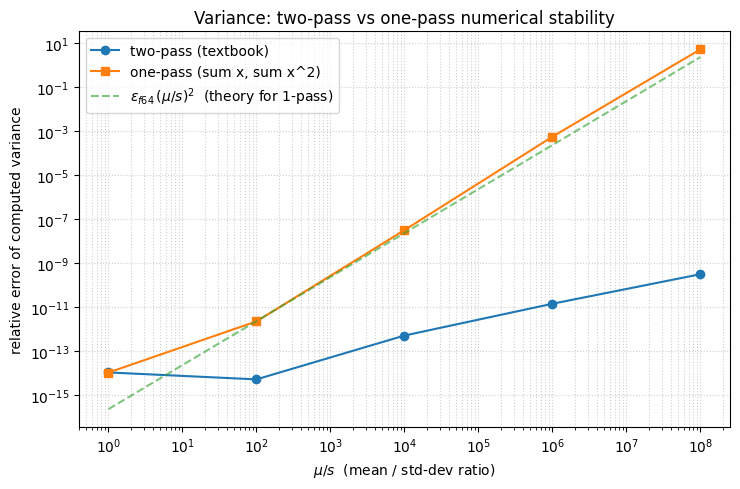

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 5))
mask = df["mu/s"] > 0          # log scale 용
ax.loglog(df.loc[mask, "mu/s"], df.loc[mask, "|rel err| 2p"], "o-", label="two-pass (textbook)")
ax.loglog(df.loc[mask, "mu/s"], df.loc[mask, "|rel err| 1p"], "s-", label="one-pass (sum x, sum x^2)")

# 이론선: eps_mach * (mu/s)^2
eps = np.finfo(np.float64).eps
ax.loglog(df.loc[mask, "mu/s"], eps * (df.loc[mask, "mu/s"]) ** 2, "--",
          alpha=0.6, label=r"$\varepsilon_{f64}\,(\mu/s)^2$  (theory for 1-pass)")

ax.set_xlabel(r"$\mu / s$  (mean / std-dev ratio)")
ax.set_ylabel("relative error of computed variance")
ax.set_title("Variance: two-pass vs one-pass numerical stability")
ax.grid(True, which="both", ls=":", alpha=0.6)
ax.legend()
plt.tight_layout()
plt.show()


In [5]:
# 같은 데이터지만 한쪽은 평균을 먼저 빼고 합 — 즉 어떤 의미에서 "shift" 만 해도 1-pass가 살아난다는 점을 시연
def var_one_pass_shifted(x):
    x = np.asarray(x, dtype=np.float64)
    n = x.size
    K = x[0]                  # 임의의 shift (첫 표본을 사용)
    y = x - K
    s1 = y.sum()
    s2 = (y * y).sum()
    return s2 / n - (s1 / n) ** 2

rows2 = []
for mu in mus:
    x = base + mu
    rows2.append({
        "mu": mu,
        "1-pass naive":   var_one_pass(x),
        "1-pass shifted": var_one_pass_shifted(x),
        "reference":      var_reference(x),
    })
df2 = pd.DataFrame(rows2)
df2


,mu,1-pass naive,1-pass shifted,reference
0,0.0000e+00,9.9947e-01,9.9947e-01,9.9947e-01
1,1.0000e+00,9.9947e-01,9.9947e-01,9.9947e-01
2,1.0000e+02,9.9947e-01,9.9947e-01,9.9947e-01
3,1.0000e+04,9.9947e-01,9.9947e-01,9.9947e-01
4,1.0000e+06,1.0000e+00,9.9947e-01,9.9947e-01
5,1.0000e+08,6.0000e+00,9.9947e-01,9.9947e-01


## 4. 결과 해석

1. **two-pass 공식**은 $\mu$ 가 아무리 커져도 상대오차가 거의 일정하게 머문다 — 평균을 먼저 빼서 $\mathcal{O}(s)$ 단위의 작은 수들만 제곱해 더하기 때문이다.
2. **one-pass 공식**은 이론선 $\varepsilon_{\text{mach}}(\mu/s)^2$ 에 정확히 맞추어 상대오차가 폭증한다. $\mu/s \approx 10^8$ 부근에서 결과가 음수로 떨어지며, 이는 부동소수점 산술이 본질적으로 만들어낸 **분산의 부호 위반**이다.
3. 같은 1-pass라도 임의의 상수 $K$ 를 빼주는 *shifted one-pass* 만으로도 정확도가 크게 회복된다 — 핵심은 *공식의 형태*가 아니라 **연산 도중에 등장하는 가장 큰 수의 크기**라는 점.
4. 실무적으로는 *Welford 알고리즘* 처럼 평균을 점진적으로 갱신하면서 $M_2$ 를 누적하는 것이 정석.

### 결론
> **대수적으로 같은 두 공식이라도, 부동소수점 산술에서는 *상쇄(cancellation)* 의 위치가 다르면 결과가 다르다. one-pass 분산 공식은 $\mu \gg s$ 일 때 사용하면 안 된다.**

### 다음 문제 연결
- **CE 1.1.9 (precision)**: 동일한 계산을 float32 / float64 두 가지 정밀도로 돌려, "어디까지 자릿수가 살아남는가" 를 정량화한다. 분산뿐 아니라 정밀도 자체가 결과의 *지배적 변수*임을 확인.
- §2 이후의 선형대수 단원에서는 같은 *cancellation* 이 행렬 분해 (LU, QR) 의 안정성을 좌우한다.
